# SKI Combinator Calculus

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from ski import *

In [4]:
p = [ "S", [ "K", ["S", "I"]] , ["S", ["K", "K"]] , "x", "y"]
exprToStr(p)

'S(K(SI))(S(KK))xy'

In [5]:
p_ski=SKI.from_list(p)
print(p_ski)

S(K(SI))(S(KK))xy


In [37]:
expr=abstract(expr=["y","x"], var="x")
expr

['S', ['K', 'y'], 'I']

In [39]:
abstract(["x", "z",'I', 'y'], var="x")

['S', ['S', ['S', 'I', ['K', 'z']], ['K', 'I']], ['K', 'y']]

In [36]:
abstract(['S', 'K', "y", ['K', 'x']], var="x")

['S', ['K', ['S', 'K', 'y']], ['S', ['K', 'K'], 'I']]

In [9]:
exprToStr(abstract(['S', ['S', 'I', ['K', 'K']], ['K', 'x']], "x"))

'S(K(S(SI(KK))))(S(KK)I)'

In [11]:
# TRUE: \xy.x   or Fxy=x
simplify(SKI_solve(expr=["x"], vars=["x", "y"]))

['K']

In [12]:
# FALSE: \xy.y   or Fxy=y
simplify(SKI_solve(expr=["y"], vars=["x", "y"]))

['K', 'I']

In [10]:
# SWAP: \xy.yx   or Fxy=yx
SKI_solve(expr=["y", "x"], vars=["x", "y"])

['S', ['K', ['S', 'I']], ['S', ['K', 'K'], 'I']]

## OR, AND, XNOR,...

In [12]:
# NOT: λfxy.fyx
expr, vars=from_lambda("λfxy.fyx")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("Reduced:",exprToStr(repeat_reduce(expr+vars)))

['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], 'I']]], ['K', 'K']]
S(S(KS)(S(KK)(S(KS)I)))(KK)
K K ) I S K ) S )) K K ) S )) S K ) S )) S ))
Reduced: fyx


In [13]:
# OR: λpq.ppq   or Fpq=ppq
expr, vars=from_lambda("λpq.ppq")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("Reduced:",exprToStr(repeat_reduce(expr+vars)))

['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', 'I', 'I']]], ['K', 'I']]
S(S(KS)(S(KK)(SII)))(KI)
I K ) I I S )) K K ) S )) S K ) S )) S ))
Reduced: ppq


Now for `AND` let's use `from_lambda`, which takes a lambda abstraction and returns a SKI expression, which we print and also convert to FORTH.

In [14]:
# AND: λpq.pqp   or Fpq=pqp
expr, vars=from_lambda("λpq.pqp")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("Reduced:",exprToStr(repeat_reduce(expr+vars)))

['S', ['S', ['K', 'S'], 'I'], 'K']
S(S(KS)I)K
K I S K ) S )) S ))
Reduced: pqp


In [25]:
# NAND: λpq.p(q(KI)(K))K
expr, vars=from_lambda("λpq.p(q(KI)K)K")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("Reduced:",exprToStr(repeat_reduce(expr+vars)))

['S', ['S', ['K', 'S'], ['S', ['S', ['K', 'S'], 'K'], ['K', ['S', ['S', 'I', ['K', ['K', 'I']]], ['K', 'K']]]]], ['K', ['K', 'K']]]
S(S(KS)(S(S(KS)K)(K(S(SI(K(KI)))(KK)))))(K(KK))
KK K ) KK KI K ) I S )) S )) K ) K KS S )) S )) KS S )) S ))
Reduced: p(q(KI)K)K


Now `XNOR`, which is also the `EQUALITY` combinator (boolean)

In [26]:
# Derive XNOR from the Lambda expression XNORpq = λpq.p(q(K)(KI))(q(KI)(K))
# XNOR = EQUALITY combinator

expr, vars=from_lambda("λpq.p(q(K)(KI))(q(KI)(K))")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("Reduced:",exprToStr(repeat_reduce(expr+vars)))

['S', ['S', ['K', 'S'], ['S', ['S', ['K', 'S'], 'K'], ['K', ['S', ['S', 'I', ['K', 'K']], ['K', ['K', 'I']]]]]], ['K', ['S', ['S', 'I', ['K', ['K', 'I']]], ['K', 'K']]]]
S(S(KS)(S(S(KS)K)(K(S(SI(KK))(K(KI))))))(K(S(SI(K(KI)))(KK)))
KK KI K ) I S )) S )) K ) KI K ) KK I S )) S )) K ) K KS S )) S )) KS S )) S ))
Reduced: p(qK(KI))(q(KI)K)


In [27]:
# SUCCessor : λnfx.f(nfx)     --> S(S(KS)K)

expr, vars=from_lambda("λnfx.f(nfx)")
print("Vars:", vars)

print("From Lambda:", expr)
expr = simplify(expr)

print("From Lambda:", exprToStr(expr))

print("Forth:", forth_ski(expr))

print("Reduced:",repeat_reduce(expr+vars))

Vars: ['n', 'f', 'x']
From Lambda: ['S', ['K', ['S', ['S', ['K', 'S'], 'K']]], ['S', ['S', ['K', 'S'], ['S', ['K', ['S', ['K', 'S']]], ['S', ['K', ['S', ['K', 'K']]], ['S', ['S', ['K', 'S'], 'K'], ['K', 'I']]]]], ['K', ['K', 'I']]]]
From Lambda: S(K(S(S(KS)K)))(S(S(KS)(S(K(S(KS)))(S(K(S(KK)))I)))(K(KI)))
Forth: KI K ) I KK S ) K ) S )) KS S ) K ) S )) KS S )) S )) K KS S )) S ) K ) S ))
Reduced: ['f', ['n', 'f', 'x']]


    one = succ 0
    add x y = x succ y
    mul x y = x (add y)

## Deriving ADD

In [6]:
# ADD: add x y = x succ y

# let f be SUCC:
expr, vars=from_lambda("λxy.xfy")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("Reduced:",exprToStr(repeat_reduce(expr+vars)))

['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', 'I', ['K', 'f']]]], ['K', 'I']]
S(S(KS)(S(KK)(SI(Kf))))(KI)
I K ) f K ) I S )) K K ) S )) S K ) S )) S ))
Reduced: xfy


In [18]:
# let replace f by S(S(KS)K):
expr = SKI.from_str("S(S(KS)(S(KK)(SI(K(S(S(KS)K))))))(KI)")
print(expr)
print(expr.to_forth())


S(S(KS)(S(KK)(SI(K(S(S(KS)K))))))(KI)
I K ) K S K ) S )) S ) K ) I S )) K K ) S )) S K ) S )) S ))


Smaller definition of ADD:

In [11]:
expr = SKI.from_str("S(KS)(S(K(S(KS)K)))")
print(expr)
expr.to_forth()


S(KS)(S(K(S(KS)K)))


'K S K ) S )) K ) S ) S K ) S ))'

##  Deriving MUL (Multiplication combinator)

https://cs.stackexchange.com/questions/86990/how-do-i-arrive-at-the-multiplication-function-in-lambda-calculus

mult := λxyf.x(yf)


In [6]:
# MUL: mul x y = x (ADD y) , let ADD be f:  λxy.x(fy)

expr, vars=from_lambda("λxyf.x(yf)")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("Reduced:",exprToStr(repeat_reduce(expr+vars)))

['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], 'K']]], ['K', 'I']]
S(S(KS)(S(KK)(S(KS)K)))(KI)
I K ) K S K ) S )) K K ) S )) S K ) S )) S ))
Reduced: x(yf)


### is0

In [22]:
# λn.n(KF)T
expr, vars=from_lambda("λn.n(KF)K")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("simplified:", forth_ski(expr, simplify=True))
print("Reduced:",exprToStr(repeat_reduce(expr+vars, verbose=True)))

['S', ['S', 'I', ['K', ['K', 'F']]], ['K', 'K']]
S(SI(K(KF)))(KK)
K K ) F K ) K ) I S )) S ))
simplified: KK KF K ) I S )) S ))
['S', ['S', 'I', ['K', ['K', 'F']]], ['K', 'K'], 'n']  -->  S(SI(K(KF)))(KK)n
['S', 'I', ['K', ['K', 'F']], 'n', ['K', 'K', 'n']]  -->  SI(K(KF))n(KKn)
['I', 'n', ['K', ['K', 'F'], 'n'], ['K', 'K', 'n']]  -->  In(K(KF)n)(KKn)
['n', ['K', ['K', 'F'], 'n'], ['K', 'K', 'n']]  -->  n(K(KF)n)(KKn)
['n', ['K', 'F'], 'K']  -->  n(KF)K
Reduced: n(KF)K


### PRED

In [24]:
# We need to define α : p -> V(pF)(  SUCC (pF)  )

# We write SUCC as +: λp.V(pF)(+(pF))

expr, vars=from_lambda("λp.V(pF)(+(pF))")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("simplified:", forth_ski(expr, simplify=True))
print("Reduced:",exprToStr(repeat_reduce(expr+vars, verbose=True)))

['S', ['S', ['K', 'V'], ['S', 'I', ['K', 'F']]], ['S', ['K', '+'], ['S', 'I', ['K', 'F']]]]
S(S(KV)(SI(KF)))(S(K+)(SI(KF)))
F K ) I S )) + K ) S )) F K ) I S )) V K ) S )) S ))
simplified: 2ND + K ) S )) 2ND V K ) S )) S ))
['S', ['S', ['K', 'V'], ['S', 'I', ['K', 'F']]], ['S', ['K', '+'], ['S', 'I', ['K', 'F']]], 'p']  -->  S(S(KV)(SI(KF)))(S(K+)(SI(KF)))p
['S', ['K', 'V'], ['S', 'I', ['K', 'F']], 'p', ['S', ['K', '+'], ['S', 'I', ['K', 'F']], 'p']]  -->  S(KV)(SI(KF))p(S(K+)(SI(KF))p)
['K', 'V', 'p', ['S', 'I', ['K', 'F'], 'p'], ['S', ['K', '+'], ['S', 'I', ['K', 'F']], 'p']]  -->  KVp(SI(KF)p)(S(K+)(SI(KF))p)
['V', ['S', 'I', ['K', 'F'], 'p'], ['S', ['K', '+'], ['S', 'I', ['K', 'F']], 'p']]  -->  V(SI(KF)p)(S(K+)(SI(KF))p)
['V', ['I', 'p', ['K', 'F', 'p']], ['K', '+', 'p', ['S', 'I', ['K', 'F'], 'p']]]  -->  V(Ip(KFp))(K+p(SI(KF)p))
['V', ['p', ['K', 'F', 'p']], ['+', ['S', 'I', ['K', 'F'], 'p']]]  -->  V(p(KFp))(+(SI(KF)p))
['V', ['p', 'F'], ['+', ['I', 'p', ['K', 'F', 'p']]]]  -->

In [25]:
# PRED: λn.( n α Z )K  with Z = (0,0)

expr, vars=from_lambda("λn.( n α Z )K")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("simplified:", forth_ski(expr, simplify=True))
print("Reduced:",exprToStr(repeat_reduce(expr+vars, verbose=True)))

['S', ['S', ['S', 'I', ['K', 'α']], ['K', 'Z']], ['K', 'K']]
S(S(SI(Kα))(KZ))(KK)
K K ) Z K ) α K ) I S )) S )) S ))
simplified: KK Z K ) α K ) I S )) S )) S ))
['S', ['S', ['S', 'I', ['K', 'α']], ['K', 'Z']], ['K', 'K'], 'n']  -->  S(S(SI(Kα))(KZ))(KK)n
['S', ['S', 'I', ['K', 'α']], ['K', 'Z'], 'n', ['K', 'K', 'n']]  -->  S(SI(Kα))(KZ)n(KKn)
['S', 'I', ['K', 'α'], 'n', ['K', 'Z', 'n'], ['K', 'K', 'n']]  -->  SI(Kα)n(KZn)(KKn)
['I', 'n', ['K', 'α', 'n'], ['K', 'Z', 'n'], ['K', 'K', 'n']]  -->  In(Kαn)(KZn)(KKn)
['n', ['K', 'α', 'n'], ['K', 'Z', 'n'], ['K', 'K', 'n']]  -->  n(Kαn)(KZn)(KKn)
['n', 'α', 'Z', 'K']  -->  nαZK
Reduced: nαZK


# Y Combinator

In [8]:
Y_expr="S(K(SII))(S(S(KS)K)(K(SII)))"
y_ski=SKI.from_str(Y_expr)
y_ski.to_forth()

'I I S )) K ) K S K ) S )) S )) I I S )) K ) S ))'

This gives an immediate stack overflow in gForth.

- See [Haskell to Javascript backend | @UHC](https://utrechthaskellcompiler.wordpress.com/2010/10/18/haskell-to-javascript-backend/)
- See the Z combinator in https://en.wikipedia.org/w/index.php?title=Fixed-point_combinator&section=13
- Y CBV https://www.cs.cornell.edu/courses/cs6110/2017sp/lectures/lec05.pdf
- [𝐖ell-𝚻yped 𝐑eflections](https://lptk.github.io/programming/2019/10/15/simple-essence-y-combinator.html)

# Looking for equalities (Simplifications)

In [142]:
repeat_reduce(['S', 'I', 'I']+["x"], verbose=True)

['S', 'I', 'I', 'x']  -->  SIIx
['I', 'x', ['I', 'x']]  -->  Ix(Ix)
['x', ['I', 'x']]  -->  x(Ix)
['x', 'x']  -->  xx


['x', 'x']

In [143]:
repeat_reduce(['S', ['S', ['K', 'S'], 'K'], ['K', 'I']]+["x", "y"], verbose=True)

# = I ???

['S', ['S', ['K', 'S'], 'K'], ['K', 'I'], 'x', 'y']  -->  S(S(KS)K)(KI)xy
['S', ['K', 'S'], 'K', 'x', ['K', 'I', 'x'], 'y']  -->  S(KS)Kx(KIx)y
['K', 'S', 'x', ['K', 'x'], ['K', 'I', 'x'], 'y']  -->  KSx(Kx)(KIx)y
['S', ['K', 'x'], ['K', 'I', 'x'], 'y']  -->  S(Kx)(KIx)y
['K', 'x', 'y', ['K', 'I', 'x', 'y']]  -->  Kxy(KIxy)
['x', ['K', 'I', 'x', 'y']]  -->  x(KIxy)
['x', ['I', 'y']]  -->  x(Iy)
['x', 'y']  -->  xy


['x', 'y']

In [32]:
repeat_reduce(clean(["S", ["K", ["S", ["K", "K"]]], ["I"]] + ["x", "y"]), verbose=True)

['S', ['K', ['S', ['K', 'K']]], 'I', 'x', 'y']  -->  S(K(S(KK)))Ixy
['K', ['S', ['K', 'K']], 'x', ['I', 'x'], 'y']  -->  K(S(KK))x(Ix)y
['S', ['K', 'K'], ['I', 'x'], 'y']  -->  S(KK)(Ix)y
['K', 'K', 'y', ['I', 'x', 'y']]  -->  KKy(Ixy)
['K', ['I', 'x', 'y']]  -->  K(Ixy)
['K', ['x', 'y']]  -->  K(xy)


['K', ['x', 'y']]

In [25]:
# S(K(S(KS)))
repeat_reduce(clean(["S", ["K", ["S", ["K", "S"]]]] + ["x", "y", "z"]), verbose=True)

['S', ['K', ['S', ['K', 'S']]], 'x', 'y', 'z']  -->  S(K(S(KS)))xyz
['K', ['S', ['K', 'S']], 'y', ['x', 'y'], 'z']  -->  K(S(KS))y(xy)z
['S', ['K', 'S'], ['x', 'y'], 'z']  -->  S(KS)(xy)z
['K', 'S', 'z', ['x', 'y', 'z']]  -->  KSz(xyz)
['S', ['x', 'y', 'z']]  -->  S(xyz)


['S', ['x', 'y', 'z']]

In [15]:
repeat_reduce(['K', ['K', 'I']]+["x", "y", "z"], verbose=True)

['K', ['K', 'I'], 'x', 'y', 'z']  -->  K(KI)xyz
['K', 'I', 'y', 'z']  -->  KIyz
['I', 'z']  -->  Iz
['z']  -->  z


['z']

In [145]:
repeat_reduce(  ['S', ['K', ['S', ['K', 'K']]] ]+["a", "b", "c", "d"], verbose=True)

['S', ['K', ['S', ['K', 'K']]], 'a', 'b', 'c', 'd']  -->  S(K(S(KK)))abcd
['K', ['S', ['K', 'K']], 'b', ['a', 'b'], 'c', 'd']  -->  K(S(KK))b(ab)cd
['S', ['K', 'K'], ['a', 'b'], 'c', 'd']  -->  S(KK)(ab)cd
['K', 'K', 'c', ['a', 'b', 'c'], 'd']  -->  KKc(abc)d
['K', ['a', 'b', 'c'], 'd']  -->  K(abc)d
['a', 'b', 'c']  -->  abc


['a', 'b', 'c']

# Stuff below is rubish? (until Validation)

In [10]:
SKI_solve(["K", "y", "I", "K", "x"], ["x", "y"])

['S',
 ['K', ['S', ['S', ['S', ['S', ['K', 'K'], 'I'], ['K', 'I']], ['K', 'K']]]],
 ['S', ['K', 'K'], 'I']]

SUCC: S(S(KS)K)    --> K S K ) S )) S )

SUM: S(KS)(S(K(S(KS)K))) -->   K S K ) S )) K ) S ) S K ) S ))  ;

In [21]:
clean([['K', ['S', ['S', 'I', ['K', 'K']]]], 'x', [['S', ['K', 'K'], 'I'], 'x'], 'y'])

['K', ['S', ['S', 'I', ['K', 'K']]], 'x', ['S', ['K', 'K'], 'I', 'x'], 'y']

In [24]:
expr=['K', ["K",['x',"I","y"],["y", "S"]]]
expr=reduce(expr)

print(expr)
print(exprToStr(expr))

['K', ['x', 'I', 'y']]
K(xIy)


In [25]:
expr = SKI_solve(["y", ["K","u", "y"], "x"], ["x", "y","u"])+["x", "y", "u"]
print(expr)

['S', ['K', ['S', ['S', ['K', 'S'], ['S', ['S', ['K', 'S'], ['S', ['K', 'K'], 'I']], ['S', ['K', ['S', ['S', ['K', 'K'], 'I']]], ['S', ['K', 'K'], 'I']]]]]], ['S', ['K', 'K'], ['S', ['K', 'K'], 'I']], 'x', 'y', 'u']


In [26]:
expr=reduce(["y", ["K","u", "y"], "x"])
print(expr)

['y', 'u', 'x']


In [74]:
# SWAP : \xy.yx

vars=["x", "y"]
expr = simplify(SKI_solve(expr=["y", "x"],vars=vars) + vars)
print(expr)

expr = repeat_reduce(expr)
print(expr)

['S', ['K', ['S', 'I']], 'K', 'x', 'y']
['y', 'x']


In [71]:
repeat_reduce( [['S', ['K', ['S', 'I']], ['S', ['K', 'K'], 'I'], 'x', 'y'], 'x', 'y'] )

['y', 'x', 'x', 'y']

In [ ]:
Simplification:

'S', ['K', 'K'], 'I' --> = 'K'
'S', 'K' --> 'K', 'I'

(can only be substituted in the beginning of a LIST! not in the middle)

In [31]:
expr = SKI_solve(expr=["y", "x"],vars=["x", "y"])+["x", "y"]
exprToStr(expr)


'S(K(SI))(S(KK)I)xy'

In [34]:
expr=simplify(expr)
exprToStr(expr)

'S(K(SI))Kxy'

In [35]:
expr=repeat_reduce(expr)
exprToStr(expr)

'yx'

In [41]:
parse("S(K(S))I")

['S', ['K', 'S'], 'I']

In [37]:
# Derive NOT from the Lambda expression NOT = \fxy.fyx

# \vars.body:
vars=["f", "x", "y"]
body=["f", "y", "x"]

expr = SKI_solve(vars=vars, expr=body)
print(expr)

print("Derived   :", expr)

expr=simplify(expr)
print("Simplified:", exprToStr(expr))
print("FORTH:", forth_ski(expr=expr))

# expr = repeat_reduce(expr+vars)
expr = repeat_reduce(expr+[["K", "I"], "x", "y"])
print("Reduced:", expr)

['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], ['S', ['S', ['K', 'S'], ['S', ['K', 'K'], 'I']], ['K', 'I']]]]], ['K', ['S', ['K', 'K'], 'I']]]
Derived   : ['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], ['S', ['S', ['K', 'S'], ['S', ['K', 'K'], 'I']], ['K', 'I']]]]], ['K', ['S', ['K', 'K'], 'I']]]
Simplified: S(S(KS)(S(KK)(S(KS)(S(S(KS)K)(KI)))))(KK)
FORTH: K K ) I K ) K S K ) S )) S )) S K ) S )) K K ) S )) S K ) S )) S ))
Reduced: ['x']


In [ ]:
\fxy.fyx

Apply NOT to TRUE:

NOT(T)xy --> Tyx --> y  ie. Fxy
NOT(F)xy --> Fyx --> x  ie. Txy

In [62]:
# Derive XNOR from the Lambda expression XNORpq = \pq.p(q(K)(KI))(q(KI)(K))
# XNOR = EQUALITY combinator

# \vars.body:
vars=parse("pq")
body=parse("p(q(K)(KI))(q(KI)(K))")

expr = SKI_solve(vars=vars, expr=body) + vars
print("Derived   :", expr)
print(exprToStr(expr))

expr=simplify(expr)
print("Simplified:",expr)
print(exprToStr(expr))

expr = repeat_reduce(expr)
print(expr)
print(exprToStr(expr))


Derived   : ['S', ['S', ['K', 'S'], ['S', ['S', ['K', 'S'], ['S', ['K', 'K'], 'I']], ['K', ['S', ['S', 'I', ['K', 'K']], ['K', ['K', 'I']]]]]], ['K', ['S', ['S', 'I', ['K', ['K', 'I']]], ['K', 'K']]], 'p', 'q']
S(S(KS)(S(S(KS)(S(KK)I))(K(S(SI(KK))(K(KI))))))(K(S(SI(K(KI)))(KK)))pq
Simplified: ['S', ['S', ['K', 'S'], ['S', ['S', ['K', 'S'], 'K'], ['K', ['S', ['S', 'I', ['K', 'K']], ['K', ['K', 'I']]]]]], ['K', ['S', ['S', 'I', ['K', ['K', 'I']]], ['K', 'K']]], 'p', 'q']
S(S(KS)(S(S(KS)K)(K(S(SI(KK))(K(KI))))))(K(S(SI(K(KI)))(KK)))pq
['p', ['q', 'K', ['K', 'I']], ['q', ['K', 'I'], 'K']]
p(qK(KI))(q(KI)K)


In [18]:
# NAND 
lambda_nand="λpq.p(q(KI)(K))K"

expr, v = from_lambda(lambda_nand)
expr += v
print("Derived   :", expr)
print(exprToStr(expr))

expr=simplify(expr)
print("Simplified:",expr)
print(exprToStr(expr))

expr = repeat_reduce(expr)
print(expr)
print(exprToStr(expr))

expr, v = from_lambda(lambda_nand)
print(forth_ski(expr))

Derived   : ['S', ['S', ['K', 'S'], ['S', ['S', ['K', 'S'], 'K'], ['K', ['S', ['S', 'I', ['K', ['K', 'I']]], ['K', 'K']]]]], ['K', ['K', 'K']], 'p', 'q']
S(S(KS)(S(S(KS)K)(K(S(SI(K(KI)))(KK)))))(K(KK))pq
Simplified: ['S', ['S', ['K', 'S'], ['S', ['S', ['K', 'S'], 'K'], ['K', ['S', ['S', 'I', ['K', ['K', 'I']]], ['K', 'K']]]]], ['K', ['K', 'K']], 'p', 'q']
S(S(KS)(S(S(KS)K)(K(S(SI(K(KI)))(KK)))))(K(KK))pq
['p', ['q', ['K', 'I'], 'K'], 'K']
p(q(KI)K)K
K K ) K ) K K ) I K ) K ) I S )) S )) K ) K S K ) S )) S )) S K ) S )) S ))


## Validation...

In [60]:
I = lambda x: x
K = lambda x: lambda y: x
S = lambda x: lambda y: lambda z: x(z)(y(z))

def from_c(n):
  return n(lambda x: x+1)(0)

def parse_ski(s):
  stack = [I]
  for c in s:
    if c in 'SKI': stack[-1] = stack[-1](eval(c))
    elif c == '(': stack.append(I)
    elif c == ')': b = stack.pop(); a = stack.pop(); stack.append(a(b))
  return stack[-1]

# SKI expressions of Church 0, 1, 2
print(from_c(parse_ski('KI')))
print(from_c(parse_ski('I')))
print(from_c(parse_ski('S(S(KS)K)I')))


0
1
2


In [69]:
def from_bool(b):
  return b(lambda x: True)(lambda x: False)(0)

# Equality

from_bool(parse_ski("S(S(KS)(S(S(KS)K)(K(S(SI(KK))(K(KI))))))(K(S(SI(K(KI)))(KK)))(K)(KI)"))

False

https://tio.run/##jVFNa4NAEL37KwYvmQUbWnqzeBWWPepNJKxxpRKjy2ogH@S329nVapNSqAdn5r03n6svw2fXvo8jhwgaeSxKCecQzl5luuOu6LpmxYsQClw1qTkp9iOOZdMT8Mo8rz/U0Q187ofAA/AF2VU3exfqQlzyBzd7V1LhleGFfiyAu@eVqoJlOCxY6AEYNZxM@9/pXAktTa92NCj2rkQ/yP2Bds14TlHVGdhD3UJvOYC6msNDHU7S7OUtJ/niI1HZPmdOrhqXEEWwwc2csJVaq7ZE/kvCSFJ819rqTiP7APkMPBSRtDhbF1@mcKffnnQpB4U318hP6cLrtvQYLJiI@IngCxM9MgkmKBKGsxUMhfU5CsGsLzhz3wJPiKOZLXqnq9uTqrM29owZtUhTP7Amdiaeojj2IXcn16ZuB7QJhIdErm@@TmZpajGOXw

In [107]:
I = lambda x: x
from_bool = lambda b: b(lambda x: True)(lambda x: False)(0)

ski={ "I": I, "K": lambda x: lambda y: x, "S": lambda x: lambda y: lambda z: x(z)(y(z)), }

def parse_ski(s):
  stack = [I]
  for c in s:
    if c in ski: stack[-1] = stack[-1](ski[c])
    elif c == '(': stack.append(I)
    elif c == ')': b = stack.pop(); a = stack.pop(); stack.append(a(b))
  return stack[-1]

ski.update({
    "T": parse_ski("K"),
    "F": parse_ski("KI"),
    "=": parse_ski("S(S(KS)(S(S(KS)K)(K(S(SI(KK))(K(KI))))))(K(S(SI(K(KI)))(KK)))"), # Equality / XNOR
    "?": parse_ski("S(S(KS)(S(S(KS)K)(K(S(SI(K(KI)))(KK)))))(K(KK))"), # NAND
})

for expr in [ "=TT", "=TF", "=FT", "=FF" ]:
   print(expr, ":", from_bool(parse_ski(expr)))

# for expr in [ "?TT", "?TF", "?FT", "?FF" ]:
#    print(expr, ":", from_bool(parse_ski(expr)))

=TT : True
=TF : False
=FT : False
=FF : True


# SKI to FORTH's SKI

    Successor: S(S(KS)K)    --> K S K ) S )) S )

    SUM = S(KS)(S(K(S(KS)K)))

    : SUM   K S K ) S )) K ) S ) S K ) S ))  ;

In [110]:
expr=parse("S(KS)(S(K(S(KS)K)))")
expr

['S', ['K', 'S'], ['S', ['K', ['S', ['K', 'S'], 'K']]]]

In [24]:
NOT=['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], ['S', ['S', ['K', 'S'], 'K'], ['K', 'I']]]]], ['K', 'K']]

forth_ski(NOT)

'K K ) I K ) K S K ) S )) S )) S K ) S )) K K ) S )) S K ) S )) S ))'

# Object Oriented SKI

In [1]:
expr=SKI("SKK(SI)F")
str(expr)

NameError: name 'SKI' is not defined

In [67]:
FALSE = SKI.from_list(["K", "I"])
# FALSE = SKI.from_str("KIK")
FALSE.to_forth()

'I K )'

In [29]:
a = SKI("KI")
b = SKI("SK")

c = (a * b)
print(c)

KISK


Podriamos escribir cualquier funcion logica booleana

por ejemplo AND: translate(lambda x,y : x & y)




p( q( f(True, True)  )( f(True, False) ) )( q( f(False, True)  )( f(False, False) ) )

In [25]:
f = lambda x,y : x & y

"K" if f(True, False) else "KI"

'KI'

In [ ]:
print(a+b)


a+b

## Pair / Vireo

In [28]:
# Vireo / Pair : λabf.fab
expr, vars=from_lambda("λabf.fab")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("Reduced:",exprToStr(repeat_reduce(expr+vars, verbose=True)))

['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], ['S', ['K', ['S', 'I']], 'K']]]], ['K', 'K']]
S(S(KS)(S(KK)(S(KS)(S(K(SI))K))))(KK)
KK K I S ) K ) S )) KS S )) KK S )) KS S )) S ))
['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], ['S', ['K', ['S', 'I']], 'K']]]], ['K', 'K'], 'a', 'b', 'f']  -->  S(S(KS)(S(KK)(S(KS)(S(K(SI))K))))(KK)abf
['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], ['S', ['K', ['S', 'I']], 'K']]], 'a', ['K', 'K', 'a'], 'b', 'f']  -->  S(KS)(S(KK)(S(KS)(S(K(SI))K)))a(KKa)bf
['K', 'S', 'a', ['S', ['K', 'K'], ['S', ['K', 'S'], ['S', ['K', ['S', 'I']], 'K']], 'a'], ['K', 'K', 'a'], 'b', 'f']  -->  KSa(S(KK)(S(KS)(S(K(SI))K))a)(KKa)bf
['S', ['S', ['K', 'K'], ['S', ['K', 'S'], ['S', ['K', ['S', 'I']], 'K']], 'a'], ['K', 'K', 'a'], 'b', 'f']  -->  S(S(KK)(S(KS)(S(K(SI))K))a)(KKa)bf
['S', ['K', 'K'], ['S', ['K', 'S'], ['S', ['K', ['S', 'I']], 'K']], 'a', 'b', ['K', 'K', 'a', 'b'], 'f']  -->  S(KK)(S(KS)(S(K(SI))K))ab(KKab)f
['K', 'K', 'a', ['S', [

In [29]:
# Bluebird B (Composition) : λfga.f(ga)
expr, vars=from_lambda("λfga.f(ga)")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("Reduced:",exprToStr(repeat_reduce(expr+vars, verbose=True)))

['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], 'K']]], ['K', 'I']]
S(S(KS)(S(KK)(S(KS)K)))(KI)
KI K KS S )) KK S )) KS S )) S ))
['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], 'K']]], ['K', 'I'], 'f', 'g', 'a']  -->  S(S(KS)(S(KK)(S(KS)K)))(KI)fga
['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], 'K']], 'f', ['K', 'I', 'f'], 'g', 'a']  -->  S(KS)(S(KK)(S(KS)K))f(KIf)ga
['K', 'S', 'f', ['S', ['K', 'K'], ['S', ['K', 'S'], 'K'], 'f'], ['K', 'I', 'f'], 'g', 'a']  -->  KSf(S(KK)(S(KS)K)f)(KIf)ga
['S', ['S', ['K', 'K'], ['S', ['K', 'S'], 'K'], 'f'], ['K', 'I', 'f'], 'g', 'a']  -->  S(S(KK)(S(KS)K)f)(KIf)ga
['S', ['K', 'K'], ['S', ['K', 'S'], 'K'], 'f', 'g', ['K', 'I', 'f', 'g'], 'a']  -->  S(KK)(S(KS)K)fg(KIfg)a
['K', 'K', 'f', ['S', ['K', 'S'], 'K', 'f'], 'g', ['K', 'I', 'f', 'g'], 'a']  -->  KKf(S(KS)Kf)g(KIfg)a
['K', ['S', ['K', 'S'], 'K', 'f'], 'g', ['K', 'I', 'f', 'g'], 'a']  -->  K(S(KS)Kf)g(KIfg)a
['S', ['K', 'S'], 'K', 'f', ['K', 'I', 'f', 'g'], 'a']  --

In [4]:
# C Cardinal : λfab.fba
expr, vars=from_lambda("λfab.fba")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("Reduced:",exprToStr(repeat_reduce(expr+vars, verbose=True)))

['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], 'I']]], ['K', 'K']]
S(S(KS)(S(KK)(S(KS)I)))(KK)
K K ) I S K ) S )) K K ) S )) S K ) S )) S ))
['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], 'I']]], ['K', 'K'], 'f', 'a', 'b']  -->  S(S(KS)(S(KK)(S(KS)I)))(KK)fab
['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], 'I']], 'f', ['K', 'K', 'f'], 'a', 'b']  -->  S(KS)(S(KK)(S(KS)I))f(KKf)ab
['K', 'S', 'f', ['S', ['K', 'K'], ['S', ['K', 'S'], 'I'], 'f'], ['K', 'K', 'f'], 'a', 'b']  -->  KSf(S(KK)(S(KS)I)f)(KKf)ab
['S', ['S', ['K', 'K'], ['S', ['K', 'S'], 'I'], 'f'], ['K', 'K', 'f'], 'a', 'b']  -->  S(S(KK)(S(KS)I)f)(KKf)ab
['S', ['K', 'K'], ['S', ['K', 'S'], 'I'], 'f', 'a', ['K', 'K', 'f', 'a'], 'b']  -->  S(KK)(S(KS)I)fa(KKfa)b
['K', 'K', 'f', ['S', ['K', 'S'], 'I', 'f'], 'a', ['K', 'K', 'f', 'a'], 'b']  -->  KKf(S(KS)If)a(KKfa)b
['K', ['S', ['K', 'S'], 'I', 'f'], 'a', ['K', 'K', 'f', 'a'], 'b']  -->  K(S(KS)If)a(KKfa)b
['S', ['K', 'S'], 'I', 'f', ['K', 'K', 'f', 'a

In [30]:
# First : λp.pK
expr, vars=from_lambda("λp.pK")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("Reduced:",exprToStr(repeat_reduce(expr+vars, verbose=True)))

['S', 'I', ['K', 'K']]
SI(KK)
KK I S ))
['S', 'I', ['K', 'K'], 'p']  -->  SI(KK)p
['I', 'p', ['K', 'K', 'p']]  -->  Ip(KKp)
['p', ['K', 'K', 'p']]  -->  p(KKp)
['p', 'K']  -->  pK
Reduced: pK


In [36]:
# Second : λp.p(KI)
expr, vars=from_lambda("λp.p(KI)")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("Reduced:",exprToStr(repeat_reduce(expr+vars, verbose=True)))

['S', 'I', ['K', ['K', 'I']]]
SI(K(KI))
I K ) K ) I S ))
2ND
['S', 'I', ['K', ['K', 'I']], 'p']  -->  SI(K(KI))p
['I', 'p', ['K', ['K', 'I'], 'p']]  -->  Ip(K(KI)p)
['p', ['K', ['K', 'I'], 'p']]  -->  p(K(KI)p)
['p', ['K', 'I']]  -->  p(KI)
Reduced: p(KI)


In [ ]:
expr = []

Φ: (a, b) ↦ (f(a, b), g(a, b))

p ↦ V ( f (pK) ( p(KI) ) ) ( g (pK) ( p(KI) ) )


phi1:
    f=F
    g=(BSF)   \\ S=SUCC

phi1: p ↦ V ( F (pK) ( p(KI) ) ) ( BSF (pK) ( p(KI) ) )
phi1: p ↦ V ( p(KI) ) ( BSF (pK) ( p(KI) ) )

BSF (pK) ( p(KI) ) = SUCC(  F (pK) ( p(KI) )   ) = SUCC(  p(KI)  ) = SUCC(  2nd p  )

donde p(KI) := 2nd p


phi1: p ↦ V ( 2nd p ) SUCC(  2nd p  )

we'll use phi1 to define PREDecessor

PRED: n ↦ 1st ( n phi1 V 0 0 )

V 0 0 = (0,0)

phi1 (0,0) --> (0,1)


https://risingentropy.com/for-loops-and-bounded-quantifiers-in-lambda-calculus/

Φ: (a, b) ↦ (f(a, b), g(a, b))

p ↦ V ( f (pK) ( p(KI) ) ) ( g (pK) ( p(KI) ) )
(a,b) ↦ ( f a b , g a b )

phi2:
    f=(BST)
    g=f

phi2 f : p ↦ V ( BST (pK) ( p(KI) ) ) ( f (pK) ( p(KI) ) )

phi2 f : (a,b) ↦ ( (BST) a b , f a b )

BST a b = S( T a b ) = SUCC a   (a+1)

phi2 f : (a,b) ↦ ( SUCC a , f a b )


for k=n to n+2:  k=n, n+1, n+2 ie 3 loop:

2nd ( thrice ( phi2 f ) (n,a) )

will do:

Pass 1:  ( phi2 f ) (n,a) ↦ (n+1, f n a )
Pass 2:  ( phi2 f ) (n+1, f n a ) ↦ (n+2, f (n+1) (f n a) )
Pass 3:  ( phi2 f ) (n+2,  ) ↦ (n+3, f (n+2) ( f (n+1) (f n a) ) )

2nd (n+3, f (n+2) ( f (n+1) (f n a) ) ) ↦ f (n+2) ( f (n+1) (f n a) )


a es el valor inicial. En cada iteracion, tenemos nuevo valor, f(n,a)


Example:

We have flexibility of a being T, or F for example, which can select in the pair...
And f can be \kb.OR b ( Z k ) for example, donde Z seria una funcion que apliquemos a k que devuelva un boolean T o F. Y las OR-eamos. Por eso, a=F, en este caso.

valor = a OR Z(0) OR Z(1) OR Z(2) ...

(hasta el numero de veces que queramos)

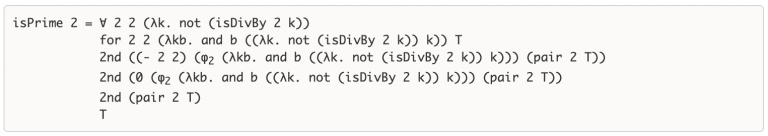




φ: p=(k, A) -> (SUCC(pK), *(pK)A)  donde *(pK)A = k*A y A=p(KI)

    * = S(S(KS)(S(KK)(S(KS)K)))(KI)
    σ = SUCC = S(S(KS)K)

λ β σ θ δ α ε π ω μ


In [37]:
# φ: λp.V(σ(pK))(*(pK)(p(KI)))
expr, vars=from_lambda("λp.V(σ(pK))(*(pK)(p(KI)))")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print(forth_ski(expr, simplify=True))

print("Reduced:",exprToStr(repeat_reduce(expr+vars, verbose=True)))

['S', ['S', ['K', 'V'], ['S', ['K', 'σ'], ['S', 'I', ['K', 'K']]]], ['S', ['S', ['K', '*'], ['S', 'I', ['K', 'K']]], ['S', 'I', ['K', ['K', 'I']]]]]
S(S(KV)(S(Kσ)(SI(KK))))(S(S(K*)(SI(KK)))(SI(K(KI))))
I K ) K ) I S )) K K ) I S )) * K ) S )) S )) K K ) I S )) σ K ) S )) V K ) S )) S ))
2ND 1ST * K ) S )) S )) 1ST σ K ) S )) V K ) S )) S ))
['S', ['S', ['K', 'V'], ['S', ['K', 'σ'], ['S', 'I', ['K', 'K']]]], ['S', ['S', ['K', '*'], ['S', 'I', ['K', 'K']]], ['S', 'I', ['K', ['K', 'I']]]], 'p']  -->  S(S(KV)(S(Kσ)(SI(KK))))(S(S(K*)(SI(KK)))(SI(K(KI))))p
['S', ['K', 'V'], ['S', ['K', 'σ'], ['S', 'I', ['K', 'K']]], 'p', ['S', ['S', ['K', '*'], ['S', 'I', ['K', 'K']]], ['S', 'I', ['K', ['K', 'I']]], 'p']]  -->  S(KV)(S(Kσ)(SI(KK)))p(S(S(K*)(SI(KK)))(SI(K(KI)))p)
['K', 'V', 'p', ['S', ['K', 'σ'], ['S', 'I', ['K', 'K']], 'p'], ['S', ['S', ['K', '*'], ['S', 'I', ['K', 'K']]], ['S', 'I', ['K', ['K', 'I']]], 'p']]  -->  KVp(S(Kσ)(SI(KK))p)(S(S(K*)(SI(KK)))(SI(K(KI)))p)
['V', ['S', ['K', 'σ'], ['S

In [14]:
# φ: λp.V(α(pK))(*(pK)A)
# φ: S(S(KV)(S(Kα)(SI(KK))))(S(S(K*)(SI(KK)))(SI(K(KI))))
# donde:
#     * = MUL  = S(S(KS)(S(KK)(S(KS)K)))(KI)
#     α = SUCC = S(S(KS)K)
# and V = PAIR = S(S(KS)(S(KK)(S(KS)(S(K(SI))K))))(KK)

# φ = "S(S(KV)(S(Kα)(SI(KK))))(S(S(K*)(SI(KK)))(SI(K(KI))))"
#           ^     ^                 ^

# I K ) K ) I S )) K K ) I S )) * K ) S )) S )) K K ) I S )) α K ) S )) V K ) S )) S ))
#                               ^-- MULT                     ^-- SUCC   ^-- PAIR

I K ) K ) I S )) K K ) I S )) MUL K ) S )) S )) K K ) I S )) SUCC K ) S )) PAIR K ) S )) S ))    CONSTANT PHI

ONE ONE PAIR )) CONSTANT (1,1)

(1,1) PHI )

In [ ]:
# FACT: λn.(n φ α)    donde α = (1,1) = V ONE ONE

In [ ]:
: .V >R CN K R@ ))) . CN KI R> ))) . ;   \  Prints a pair of two Church numerals

: .N CN ROT )) . ;    \ Prints a Church numeral

(1,1) .V 1 1  ok
(1,1) PHI )  ok
.V 2 1  ok

(1,1) PHI ) PHI ) PHI ) .V -->   4 6  ok



TWO TWO )  ok
CN ROT )) . 4  ok
TWO TWO ) CONSTANT FOUR  ok
  ok
  ok
  ok
CLS  ok
(1,1) PHI FOUR   ok
.S <3> 140628625550144 140628625548000 140628625569168  ok
) )   ok
.S <1> 140628625578688  ok
.V 5 24  ok

In [40]:
# FACT : λn.(n φ α)F    \ α = (1,1) = V ONE ONE
expr, vars=from_lambda("λn.(n φ α) F ")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print(forth_ski(expr, simplify=True))
print("Reduced:",exprToStr(repeat_reduce(expr+vars, verbose=True)))

['S', ['S', ['S', 'I', ['K', 'φ']], ['K', 'α']], ['K', 'F']]
S(S(SI(Kφ))(Kα))(KF)
F K ) α K ) φ K ) I S )) S )) S ))
KF α K ) φ K ) I S )) S )) S ))
['S', ['S', ['S', 'I', ['K', 'φ']], ['K', 'α']], ['K', 'F'], 'n']  -->  S(S(SI(Kφ))(Kα))(KF)n
['S', ['S', 'I', ['K', 'φ']], ['K', 'α'], 'n', ['K', 'F', 'n']]  -->  S(SI(Kφ))(Kα)n(KFn)
['S', 'I', ['K', 'φ'], 'n', ['K', 'α', 'n'], ['K', 'F', 'n']]  -->  SI(Kφ)n(Kαn)(KFn)
['I', 'n', ['K', 'φ', 'n'], ['K', 'α', 'n'], ['K', 'F', 'n']]  -->  In(Kφn)(Kαn)(KFn)
['n', ['K', 'φ', 'n'], ['K', 'α', 'n'], ['K', 'F', 'n']]  -->  n(Kφn)(Kαn)(KFn)
['n', 'φ', 'α', 'F']  -->  nφαF
Reduced: nφαF


In [ ]:
F K ) (1,1) K ) PHI K ) I S )) S )) S ))

In [7]:
# λfz.ffz
expr, vars=from_lambda("λfz.ffz")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("simplified:", forth_ski(expr, simplify=True))
print("Reduced:",exprToStr(repeat_reduce(expr+vars, verbose=True)))

['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', 'I', 'I']]], ['K', 'I']]
S(S(KS)(S(KK)(SII)))(KI)
I K ) I I S )) K K ) S )) S K ) S )) S ))
simplified: F I I S )) KK S )) KS S )) S ))
['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', 'I', 'I']]], ['K', 'I'], 'f', 'z']  -->  S(S(KS)(S(KK)(SII)))(KI)fz
['S', ['K', 'S'], ['S', ['K', 'K'], ['S', 'I', 'I']], 'f', ['K', 'I', 'f'], 'z']  -->  S(KS)(S(KK)(SII))f(KIf)z
['K', 'S', 'f', ['S', ['K', 'K'], ['S', 'I', 'I'], 'f'], ['K', 'I', 'f'], 'z']  -->  KSf(S(KK)(SII)f)(KIf)z
['S', ['S', ['K', 'K'], ['S', 'I', 'I'], 'f'], ['K', 'I', 'f'], 'z']  -->  S(S(KK)(SII)f)(KIf)z
['S', ['K', 'K'], ['S', 'I', 'I'], 'f', 'z', ['K', 'I', 'f', 'z']]  -->  S(KK)(SII)fz(KIfz)
['K', 'K', 'f', ['S', 'I', 'I', 'f'], 'z', ['K', 'I', 'f', 'z']]  -->  KKf(SIIf)z(KIfz)
['K', ['S', 'I', 'I', 'f'], 'z', ['K', 'I', 'f', 'z']]  -->  K(SIIf)z(KIfz)
['S', 'I', 'I', 'f', ['K', 'I', 'f', 'z']]  -->  SIIf(KIfz)
['I', 'f', ['I', 'f'], ['K', 'I', 'f', 'z']]  -->  If(If)(KIfz)
['f'

In [9]:
# λfz.ffz
expr, vars=from_lambda("λtfz.(t(ffz))(t(ffz))")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("simplified:", forth_ski(expr, simplify=True))
print("Reduced:",exprToStr(repeat_reduce(expr+vars, verbose=True)))

['S', ['S', ['K', 'S'], ['S', ['K', ['S', ['K', 'S']]], ['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], 'K']]], ['K', ['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', 'I', 'I']]], ['K', 'I']]]]]], ['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], 'K']]], ['K', ['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', 'I', 'I']]], ['K', 'I']]]]]
S(S(KS)(S(K(S(KS)))(S(S(KS)(S(KK)(S(KS)K)))(K(S(S(KS)(S(KK)(SII)))(KI))))))(S(S(KS)(S(KK)(S(KS)K)))(K(S(S(KS)(S(KK)(SII)))(KI))))
I K ) I I S )) K K ) S )) S K ) S )) S )) K ) K S K ) S )) K K ) S )) S K ) S )) S )) I K ) I I S )) K K ) S )) S K ) S )) S )) K ) K S K ) S )) K K ) S )) S K ) S )) S )) S K ) S ) K ) S )) S K ) S )) S ))
simplified: F I I S )) KK S )) KS S )) S )) K ) K KS S )) KK S )) KS S )) S )) F I I S )) KK S )) KS S )) S )) K ) K KS S )) KK S )) KS S )) S )) KS S ) K ) S )) KS S )) S ))
['S', ['S', ['K', 'S'], ['S', ['K', ['S', ['K', 'S']]], ['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', ['K', 'S'], 'K']]], ['K', 

In [ ]:
# λz.ffz
expr, vars=from_lambda("λfz.ffz")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("simplified:", forth_ski(expr, simplify=True))
print("Reduced:",exprToStr(repeat_reduce(expr+vars, verbose=True)))

['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', 'I', 'I']]], ['K', 'I']]
S(S(KS)(S(KK)(SII)))(KI)
I K ) I I S )) K K ) S )) S K ) S )) S ))
simplified: F I I S )) KK S )) KS S )) S ))
['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', 'I', 'I']]], ['K', 'I'], 'f', 'z']  -->  S(S(KS)(S(KK)(SII)))(KI)fz
['S', ['K', 'S'], ['S', ['K', 'K'], ['S', 'I', 'I']], 'f', ['K', 'I', 'f'], 'z']  -->  S(KS)(S(KK)(SII))f(KIf)z
['K', 'S', 'f', ['S', ['K', 'K'], ['S', 'I', 'I'], 'f'], ['K', 'I', 'f'], 'z']  -->  KSf(S(KK)(SII)f)(KIf)z
['S', ['S', ['K', 'K'], ['S', 'I', 'I'], 'f'], ['K', 'I', 'f'], 'z']  -->  S(S(KK)(SII)f)(KIf)z
['S', ['K', 'K'], ['S', 'I', 'I'], 'f', 'z', ['K', 'I', 'f', 'z']]  -->  S(KK)(SII)fz(KIfz)
['K', 'K', 'f', ['S', 'I', 'I', 'f'], 'z', ['K', 'I', 'f', 'z']]  -->  KKf(SIIf)z(KIfz)
['K', ['S', 'I', 'I', 'f'], 'z', ['K', 'I', 'f', 'z']]  -->  K(SIIf)z(KIfz)
['S', 'I', 'I', 'f', ['K', 'I', 'f', 'z']]  -->  SIIf(KIfz)
['I', 'f', ['I', 'f'], ['K', 'I', 'f', 'z']]  -->  If(If)(KIfz)
['f'

# Z Combinator in Python

[𝐖ell-𝚻yped 𝐑eflections](https://lptk.github.io/programming/2019/10/15/simple-essence-y-combinator.html)

In [17]:
def fact(x):
  return 1 if x == 0 else fact(x - 1) * x


In [18]:
fact(9)

362880

In [20]:
fact = (lambda x:  1 if x == 0 else fact(x - 1) * x)
fact(9)

362880

In [ ]:
fact_base = (lambda rec: lambda x:
  1 if x == 0 else rec(rec)(x - 1) * x)

We translate this to a combinator:

In [38]:
# λrx.(?x) ( 1 ) ( MUL ( (r(r))( -x ) ) x )           \ r = rec, -x = PRED x  , ?0 = IS0 x 
# λrx.(?x) ( 1 ) ( * ( (r(r))( -x ) ) x )             \ * = MUL
# λrx.?x1(*(rr(-x))x)
expr, vars=from_lambda("λrx.(?x) ( 1 ) ( * ( (r(r))( -x ) ) x )")
expr=simplify(expr)
print(expr)
print(exprToStr(expr))
print(forth_ski(expr))
print("simplified:", forth_ski(expr, simplify=True))
print("Reduced:",exprToStr(repeat_reduce(expr+vars, verbose=True)))

['S', ['K', ['S', ['S', ['S', ['K', '?'], 'I'], ['K', '1']]]], ['S', ['S', ['K', 'S'], ['S', ['K', ['S', ['K', '*']]], ['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', 'I', 'I']]], ['K', ['S', ['K', '-'], 'I']]]]], ['K', 'I']]]
S(K(S(S(S(K?)I)(K1))))(S(S(KS)(S(K(S(K*)))(S(S(KS)(S(KK)(SII)))(K(S(K-)I)))))(KI))
I K ) I - K ) S )) K ) I I S )) K K ) S )) S K ) S )) S )) * K ) S ) K ) S )) S K ) S )) S )) 1 K ) I ? K ) S )) S )) S ) K ) S ))
simplified: F I - K ) S )) K ) I I S )) KK S )) KS S )) S )) * K ) S ) K ) S )) KS S )) S )) 1 K ) I ? K ) S )) S )) S ) K ) S ))
['S', ['K', ['S', ['S', ['S', ['K', '?'], 'I'], ['K', '1']]]], ['S', ['S', ['K', 'S'], ['S', ['K', ['S', ['K', '*']]], ['S', ['S', ['K', 'S'], ['S', ['K', 'K'], ['S', 'I', 'I']]], ['K', ['S', ['K', '-'], 'I']]]]], ['K', 'I']], 'r', 'x']  -->  S(K(S(S(S(K?)I)(K1))))(S(S(KS)(S(K(S(K*)))(S(S(KS)(S(KK)(SII)))(K(S(K-)I)))))(KI))rx
['K', ['S', ['S', ['S', ['K', '?'], 'I'], ['K', '1']]], 'r', ['S', ['S', ['K', 'S'], ['S', ['K', ['S'

We translate it back to FORTH SKI:

FACT_BASE takes a REC (r) and an x:

F I PRED K ) S )) K ) I I S )) KK S )) KS S )) S )) MUL K ) S ) K ) S )) KS S )) S )) ONE K ) I IS0 K ) S )) S )) S ) K ) S ))  CONSTANT FACT_BASE



In [31]:
# fact = fact_base(fact_base)

# F I PRED K ) S )) K ) I I S )) KK S )) KS S )) S )) MUL K ) S ) K ) S )) KS S )) S )) ONE K ) I IS0 K ) S )) S )) S ) K ) S ))  CONSTANT FACT_BASE

# FACT_BASE FACT_BASE ) CONSTANT FACT      --> this still fails with a "Return stack overflow" exception

In [32]:
# assuming the curried:
fact_base = (lambda rec: lambda x:
  1 if x == 0 else rec(rec)(x - 1) * x)

# we now just write:
fact = fact_base(fact_base)

In [37]:
(lambda rec: lambda x:
  1 if x == 0 else fact_base(fact_base)(x - 1) * x)

24